# 24 — Rights-bundle lattice (groups as labels for nodes)

**Conceptual reframing.** Social categories like *Citizen*, *Noble*, *Foreigner*, *Slave* are not primitive — each is itself a bundle of rights (plus one or two primitive features like sex or birth). Putting *Citizen* on one axis of a Hasse diagram and *right to vote* on another double-counts, because a Citizen *is* (in part) "a male with the right to vote".

**Two-layer ontology.**

- **Layer 1 — primitives** (labels, not rights): sex (male / female), liberty (free / owned), origin (native / foreign). Slaves are defined here: *Slave ≔ owned*.
- **Layer 2 — rights** (this is where the Hasse lives): the 11 orthogonal rights from notebook 23. A *bundle* is a subset of these atoms.

The Hasse is the inclusion order over the bundles **actually attested in the corpus**. `Citizen`, `Noble`, `Foreigner`, `Wife`, etc. are **historical names for specific nodes** in this lattice — they are *labels on the Hasse*, not orthogonal axes to it.

**What this lets us see.**

1. The shape of the lattice is intrinsic to the rights, independent of which labels are fashionable.
2. Group labels become diachronic: "the bundle named Citizen in 500 BCE" can differ from "the bundle named Citizen in 200 CE" — and you can see the shift on the diagram.
3. The *Noble → Citizen* historical transition: in Archaic / Classical times the default-male bundle is what we call **Noble**; in late Classical and after, the default-male bundle is what we call **Citizen**. Same lattice, different label at the top male node.
4. *Slave* is defined by a **missing right** (anti-enslavement protection) — that places it structurally at the bottom of the lattice without needing a separate axis.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd

pd.set_option('display.max_colwidth', 120)

DATA_PATH = Path('../data/rules_dataset_april_2026.tsv')

PERIOD_MAP = {
    'Classical (500–360 BCE)':                      'Classical (500–360 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)': 'Roman (165 BCE – 205 CE)',
    'High Roman Empire (135–205 CE)':               'Roman (165 BCE – 205 CE)',
}
PERIOD_ORDER = ['Classical (500–360 BCE)', 'Roman (165 BCE – 205 CE)']

GREEK_POLITIES = {
    'Classical Athens', 'Hellenistic Athens', 'Archaic Athens',
    'Archaic Athens (Solonic)', 'Archaic Athens (Draconian)',
    'Archaic Athens (Peisistratid)', 'Archaic Athens (Pre-Solonic)',
    'Classical Athens (Solonic)', 'Classical Athens (Cleisthenic)',
    'Classical Athens (Eleusis)', 'Classical Athens (The Four Hundred)',
    'Classical Athens (The Five Thousand)', 'Classical Athens (the Five Thousand)',
    'Classical Sparta', 'Sparta', 'Archaic Sparta',
    'Classical Greece', 'Ancient Greece', 'Hellenistic Greece', 'Hellenistic Greek states',
    'Classical Thebes', 'Syracuse', 'Sicyon', 'Corinth', 'Aegina',
    'Mantineia', 'Mytilene', 'Oreus', 'Acragas', 'Delphi', 'Crete',
    'Chalcidice', 'Salamis (Cyprus)', 'Ionia and Pontus', 'Tarsus',
    'League of Corinth', 'Achaean League', 'Delphic Amphictyonic League',
    'Hellenistic Macedon', 'Macedonian Empire', 'Seleucid Empire',
    'Hierapolis (Syria)', 'Hellenistic Hierapolis',
    'Mythological / legendary setting',
}

RESOURCE_BUCKET = {
    'Right to own land':                          'Right to own property',
    'Right to retain own earnings':               'Right to retain property',
    'Right to dispose of property':               'Right to dispose / inherit property',
    'Right to inherit property':                  'Right to dispose / inherit property',
    'Right to inherit divine covenant':           'Right to dispose / inherit property',
    'Right to address the assembly':              'Right to public speech',
    'Right to speak first in assembly':           'Right to public speech',
    'Right to free speech':                       'Right to public speech',
    'Right to remuneration for office':           'Eligibility for public office',
    'Right to reside in the city':                'Right to reside / freedom of movement',
    'Right to freedom of movement':               'Right to reside / freedom of movement',
    'Right to a dowry':                           'Right to marriage / dowry',
    'Right to marry':                             'Right to marriage / dowry',
    'Right to professional judgement':            'Right to a legal trial',
    'Right to valid professional opinion':        'Right to a legal trial',
    'Right to military protection':               'Right to bear arms / military protection',
    'Right to bear arms':                         'Right to bear arms / military protection',
    'Protection from arbitrary banishment':       'Protection from banishment / prosecution',
    'Protection from legal prosecution':          'Protection from banishment / prosecution',
    'Protection from capital punishment':         'Protection from capital / corporal punishment',
    'Protection from corporal punishment':        'Protection from capital / corporal punishment',
    'Exemption from compulsory public financing': 'Exemption from taxes / public financing',
    'Exemption from public service financing':    'Exemption from taxes / public financing',
    'Exemption from taxes':                       'Exemption from taxes / public financing',
    'Exemption from manual labor':                'Exemption from compulsory service',
    'Exemption from military service':            'Exemption from compulsory service',
}

OPPOSITE_GROUP = {
    'Women': 'Men', 'Wives': 'Men', 'Minors': 'Men', 'Elders': 'Men', 'Sick': 'Men',
    'Orphans': 'Heirs',
    'Slaves': 'Citizens', 'Foreigners': 'Citizens', 'Exiles': 'Citizens',
    'Macedonians': 'Greeks', 'Scythians': 'Greeks', 'Syrians': 'Greeks',
    'The poor / multitude': 'The wealthy',
    # defaults — do not flip
    'Men': None, 'Heirs': None, 'Citizens': None, 'Greeks': None,
    'Spartans': None, 'The wealthy': None, 'Physicians': None,
    'Kings': None, 'Nobles': None, 'Magistrates': None, 'Artisans': None,
    'Poets': None, 'Priests': None, 'Soldiers': None, 'Sailors': None,
    'Philosophers': None, 'The educated': None,
    'Christians': None, 'Jews': None, 'Romans': None,
}

ORTHOGONAL_RIGHTS = [
    'Right to vote in the Ekklesia',
    'Eligibility for public office',
    'Right to public speech',
    'Right to dispose / inherit property',
    'Right to marriage / dowry',
    'Right to a legal trial',
    'Protection from capital / corporal punishment',
    'Right to reside / freedom of movement',
    'Access to religious rites',
    'Protection from enslavement',
    'Exemption from compulsory service',
]

# --- Atomic categories we will plot as LABELS on the lattice ---------------
# These are real group_meta atoms in the corpus, not canonical merges.
ATOMIC_GROUPS = [
    'Citizens', 'Nobles', 'Foreigners', 'Slaves', 'Exiles',
    'Men', 'Women', 'Wives',
]

MIN_RULES_PER_CELL = 1

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep='\t')

def atoms(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

base = (df_raw
          .dropna(subset=['period', 'group_meta', 'resource_meta', 'rule_polity', 'directionality'])
          .assign(period=lambda d: d['period'].map(PERIOD_MAP))
          .dropna(subset=['period']))
base = base[base['rule_polity'].isin(GREEK_POLITIES)]
base = base.assign(resource_bucket=base['resource_meta'].map(lambda r: RESOURCE_BUCKET.get(r, r)))
base = base.assign(group_atom=base['group_meta'].apply(atoms)).explode('group_atom')
base = base[base['group_atom'].isin(set(ATOMIC_GROUPS) | set(OPPOSITE_GROUP))]

more_rows = base[base['directionality'] == 'MORE'][['period', 'group_atom', 'resource_bucket']]
less_rows = base[base['directionality'] == 'LESS'][['period', 'group_atom', 'resource_bucket']]

flipped = (less_rows
             .assign(group_atom=less_rows['group_atom'].map(OPPOSITE_GROUP))
             .dropna(subset=['group_atom']))

positive = pd.concat([more_rows.assign(origin='MORE'),
                      flipped.assign(origin='flipped LESS')],
                     ignore_index=True)
positive = positive[positive['resource_bucket'].isin(ORTHOGONAL_RIGHTS)]
positive = positive[positive['group_atom'].isin(ATOMIC_GROUPS)]
positive.shape, positive['origin'].value_counts().to_dict()

((157, 4), {'MORE': 118, 'flipped LESS': 39})

## Right-bundle per atomic group per period

For each `(atomic_group, period)`, take the union of orthogonal rights attested by ≥ 1 routed rule. This bundle is the **node** in the lattice; the atomic group is its **label**.

In [3]:
def bundles_for(period):
    sub = (positive[positive['period'] == period]
             .groupby(['group_atom', 'resource_bucket'])
             .size())
    out = {}
    for (g, r), n in sub.items():
        if n < MIN_RULES_PER_CELL:
            continue
        out.setdefault(g, set()).add(r)
    return {g: frozenset(s) for g, s in out.items() if s}

bundles_classical = bundles_for('Classical (500–360 BCE)')
bundles_roman     = bundles_for('Roman (165 BCE – 205 CE)')

rows = []
for g in ATOMIC_GROUPS:
    rows.append({
        'group':            g,
        '|bundle| Classical': len(bundles_classical.get(g, frozenset())),
        '|bundle| Roman':     len(bundles_roman    .get(g, frozenset())),
    })
pd.DataFrame(rows).set_index('group')

,|bundle| Classical,|bundle| Roman
group,,
Citizens,9,9
Nobles,1,3
Foreigners,5,0
Slaves,3,0
Exiles,1,0
Men,7,7
Women,4,1
Wives,0,0


## Build the Hasse over right-bundles

Nodes are distinct frozensets (bundles); edges go from a smaller bundle to a strictly-larger one that contains it (transitive reduction). Each node is annotated with every atomic group whose bundle matches it.

In [4]:
def lattice(bundles):
    # node = right-set; label = list of groups whose bundle == this set
    by_set = {}
    for g, s in bundles.items():
        by_set.setdefault(s, []).append(g)
    nodes = list(by_set.keys())
    G = nx.DiGraph()
    for s in nodes:
        G.add_node(s, size=len(s))
    for a, b in combinations(nodes, 2):
        if a < b:           # strict subset
            G.add_edge(a, b)
        elif b < a:
            G.add_edge(b, a)
    return nx.transitive_reduction(G), by_set

def topological_positions(G):
    depth = {n: 0 for n in G.nodes}
    for n in reversed(list(nx.topological_sort(G))):
        for succ in G.successors(n):
            if depth[n] < depth[succ] + 1:
                depth[n] = depth[succ] + 1
    max_d = max(depth.values()) if depth else 0
    levels = {}
    for n in G.nodes:
        levels.setdefault(max_d - depth[n], []).append(n)
    pos = {}
    for y, ns in levels.items():
        ns = sorted(ns, key=lambda s: (len(s), sorted(s)))
        for i, n in enumerate(ns):
            pos[n] = ((i + 1) / (len(ns) + 1), y)
    return pos

G_cl, label_cl = lattice(bundles_classical)
G_ro, label_ro = lattice(bundles_roman)

print('Classical: {} bundles, {} edges'.format(len(G_cl.nodes), len(G_cl.edges)))
print('Roman:     {} bundles, {} edges'.format(len(G_ro.nodes), len(G_ro.edges)))

Classical: 7 bundles, 6 edges
Roman:     4 bundles, 1 edges


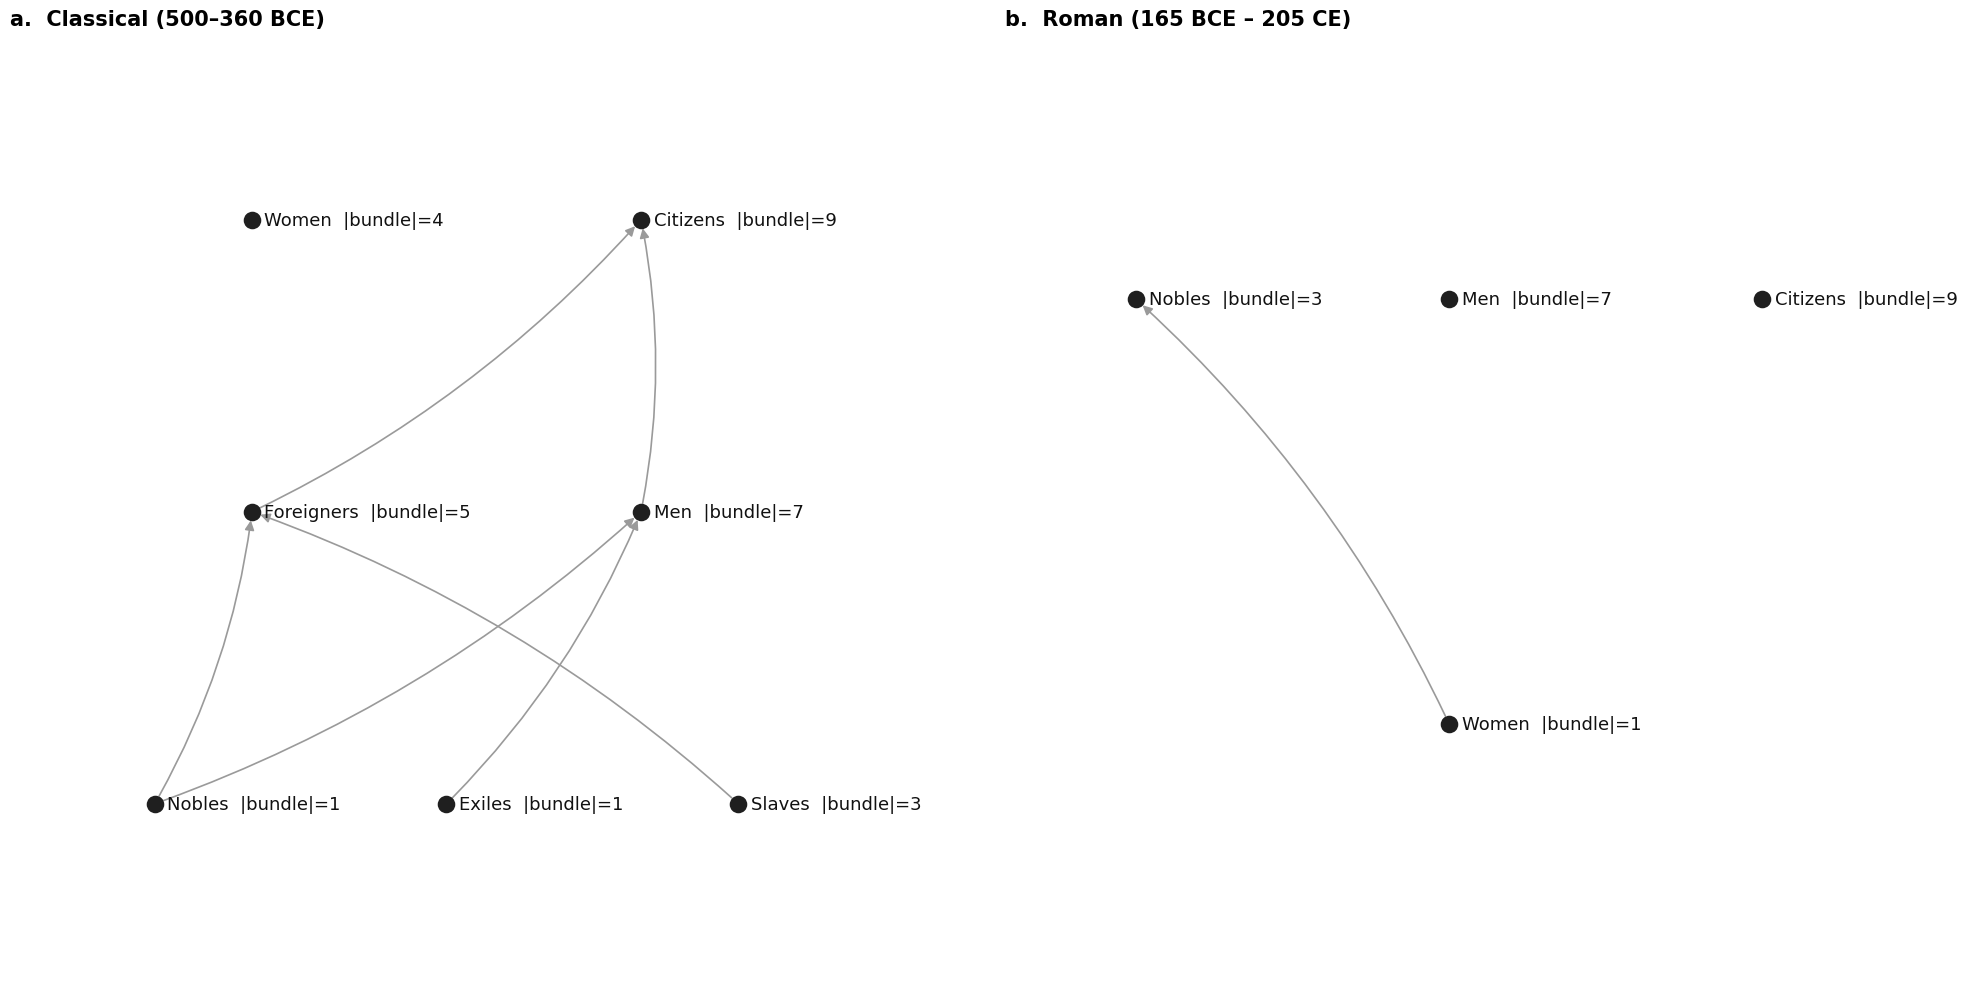

In [5]:
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.titlesize':  15,
})
NODE_SIZE = 160
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for letter, ax, (G, labels), period in zip('ab', axes,
                                            [(G_cl, label_cl), (G_ro, label_ro)],
                                            PERIOD_ORDER):
    pos = topological_positions(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=NODE_SIZE, node_color='#1f1f1f', linewidths=0)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#9a9a9a', width=1.2,
                            arrows=True, arrowstyle='-|>', arrowsize=14,
                            node_size=NODE_SIZE, connectionstyle='arc3,rad=0.10',
                            min_source_margin=5, min_target_margin=5)
    for n, (x, y) in pos.items():
        group_label = ', '.join(labels[n])
        bundle_size = len(n)
        ax.annotate(f'{group_label}  |bundle|={bundle_size}',
                    xy=(x, y), xytext=(9, 0),
                    textcoords='offset points', ha='left', va='center',
                    fontsize=13, color='#111111')
    ymax = max(y for _, y in pos.values()) if pos else 0
    ax.set_title(f'{letter}.  {period}', fontsize=15, loc='left', pad=14, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(axis='both', length=0)
    ax.set_ylim(-0.6, ymax + 0.6); ax.margins(x=0.18)
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

fig.tight_layout(w_pad=4)
plt.show()

## Inspect every bundle

For each period, list every distinct bundle and which atomic groups label it. This is where you read the *diachronic shift* — e.g. the bundle named `Nobles` in Classical may *contain* the bundle named `Citizens`, or they may collapse to one node by the Roman period.

In [6]:
def print_bundles(by_set, period):
    print(f'\n=== {period} ===')
    items = sorted(by_set.items(), key=lambda kv: (-len(kv[0]), sorted(kv[1])))
    for bundle, groups in items:
        gl = ', '.join(groups)
        body = ', '.join(sorted(bundle))
        print(f'\n{gl}  ({len(bundle)} rights)')
        print(f'  {{ {body} }}')

print_bundles(label_cl, 'Classical (500–360 BCE)')
print_bundles(label_ro, 'Roman (165 BCE – 205 CE)')


=== Classical (500–360 BCE) ===

Citizens  (9 rights)
  { Eligibility for public office, Exemption from compulsory service, Protection from capital / corporal punishment, Protection from enslavement, Right to a legal trial, Right to dispose / inherit property, Right to public speech, Right to reside / freedom of movement, Right to vote in the Ekklesia }

Men  (7 rights)
  { Eligibility for public office, Exemption from compulsory service, Protection from capital / corporal punishment, Protection from enslavement, Right to dispose / inherit property, Right to public speech, Right to reside / freedom of movement }

Foreigners  (5 rights)
  { Eligibility for public office, Protection from capital / corporal punishment, Right to a legal trial, Right to dispose / inherit property, Right to public speech }

Women  (4 rights)
  { Access to religious rites, Right to dispose / inherit property, Right to marriage / dowry, Right to public speech }

Slaves  (3 rights)
  { Protection from capital 

## How to read this

**The Hasse is over right-bundles.** Each node is a subset of the 11 orthogonal rights. Each node is annotated with the atomic group(s) whose bundle equals that subset.

**Group labels move.** If `Citizens` and `Nobles` annotate the *same* node in a period, they are observationally indistinguishable on this rights battery — the historical distinction is sub-rights-level (and could become visible with finer data, e.g. by splitting *Eligibility for public office* into *kingship* vs *archonship*).

**Slaves sit low.** *Slave* is operationalised by *not having Protection from enslavement* — but in the data slaves are also attested with a small positive bundle (legal trial, public speech in some periods). The Hasse position of the *Slaves* label therefore captures the residual positive rights attributed to slaves, while the slavery-defining absence sits implicitly *above* their node (it's a right held by every node strictly above them).

**Diachronic story.** Walk both panels: does *Citizens* sit at the same bundle in Classical and Roman? If so, citizenship as a rights bundle is stable. Does *Foreigners* climb (gain rights) from Classical → Roman? Does *Nobles* converge onto *Citizens*?